# 5-Dataset Load/Iter/Render Sanity Check

This notebook checks 5 datasets:
- BEDLAM train (`BedlamDatasetV2`)
- 3DPW train (`ThreedpwSmplDataset`)
- 3DPW test (`ThreedpwSmplFullSeqDataset`)
- EMDB test (`EmdbSmplFullSeqDataset`)
- UNI3C aligned (`Uni3CAlignedDatasetV1`)

For each dataset it verifies:
1. Dataset is instantiable and sample is loadable
2. Dataloader iteration loop runs without errors
3. A sample visualization is produced: crop image + bbox/kpts overlay + camera/world SMPLX render


In [1]:
import os
from pathlib import Path
from collections import defaultdict
import numpy as np
from tqdm import tqdm, trange
from einops import einsum
import cv2
from PIL import Image
import imageio.v3 as iio
import lovely_tensors as lt
lt.monkey_patch()
import torch
import matplotlib.pyplot as plt

from hmr4d.dataset.imgfeat_motion.uni3c_aligned import Uni3CAlignedDatasetV1
from hmr4d.utils.preproc import Tracker, Extractor, VitPoseExtractor, SimpleVO
from hmr4d.utils.geo_transform import apply_T_on_points, compute_T_ayfz2ay, make_K_crop, map_kp2d_to_crop
from hmr4d.utils.geo.hmr_cam import create_camera_sensor
from hmr4d.utils.vis.cv2_utils import draw_bbx_xys_on_image_batch, draw_kpts_with_conf_batch
from hmr4d.utils.vis.renderer import Renderer, get_global_cameras_static, get_ground_params_from_points
from hmr4d.utils.body_model import BodyModelSMPLX, BodyModelSMPLH
from hmr4d.utils.smplx_utils import make_smplx

os.environ.setdefault('CUDA_VISIBLE_DEVICES', '1')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', device)

/home/guangyu/anaconda3/envs/hmr/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


device = cuda


In [2]:
# SMPLX for rendering
smpl = BodyModelSMPLH(
    model_path="inputs/checkpoints/body_models", model_type="smpl",
    gender="neutral", num_betas=10, create_body_pose=False, 
    create_betas=False, create_global_orient=False, create_transl=False,
).to(device)
smpl.eval()

smplx = BodyModelSMPLX(
    model_path='inputs/checkpoints/body_models',
    model_type='smplx',
    gender='neutral',
    num_pca_comps=12,
    flat_hand_mean=False,
).to(device)
smplx.eval()

smplx2smpl = torch.load("hmr4d/utils/body_model/smplx2smpl_sparse.pt").to(device)
J_regressor = torch.load("hmr4d/utils/body_model/smpl_neutral_J_regressor.pt").to(device)

smplx_coco = make_smplx("supermotion_v437coco17").to(device)
smplx_coco.eval()

tracker = Tracker()
vitpose_extractor = VitPoseExtractor()

/tmp/ipykernel_1066245/643709880.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  smplx2smpl = torch.load("hmr4d/utils/body_model/smplx2smpl_sparse.pt").to(device)
/tmp/

In [3]:
ds = Uni3CAlignedDatasetV1(load_image=True, random=False, load_indices=[0, -1])

[02/16 13:18:43][INFO] [UNI3C_SynthGenerated] Loading from inputs/uni3c_aligned ...
[02/16 13:18:43][INFO] [UNI3C_SynthGenerated] Loaded from 342 synthetic samples
[02/16 13:18:43][INFO] [UNI3C_SynthGenerated] Using 342 synthetic samples


In [21]:
sample = ds[120]

In [22]:
video_path = sample['meta']['vid']
vitpose = vitpose_extractor.extract(str(video_path), bbx_xys=sample['bbx_xys'])  # (F,17,3)

ViTPose: 100%|██████████| 8/8 [00:05<00:00,  1.50it/s]


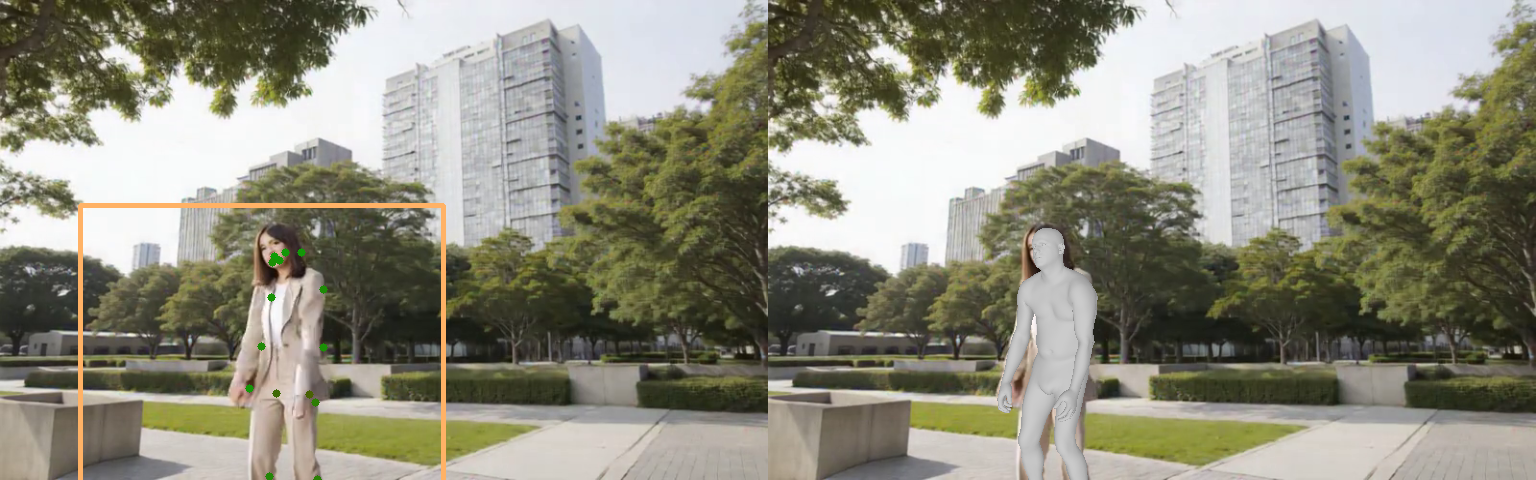

In [24]:
i = 10

K_fullimg = sample["K_fullimg"][0]
width, height = int(K_fullimg[0,2].item() * 2), int(K_fullimg[1,2].item() * 2)

origin_frame_1 = cv2.resize(iio.imread(video_path, index=i), (width, height))
origin_frame_1_annot = draw_bbx_xys_on_image_batch(sample['bbx_xys'][i:i+1], [origin_frame_1], thickness=4)[0]
origin_frame_1_annot = draw_kpts_with_conf_batch(
    [origin_frame_1_annot[..., ::-1]], vitpose[i:i+1, ..., :2], 
    torch.clamp((vitpose[i:i+1, ...,  2] - 0.5) * 2, 0.0, 1.0), 
    thickness=4)[0][...,::-1]


renderer_c = Renderer(width, height, device="cuda", faces=smplx.faces, K=K_fullimg)
smpl_params_c = {k:v.to(device) for k,v in sample['smpl_params_c'].items()}
verts = smplx(**smpl_params_c).vertices
render_img = renderer_c.render_mesh(verts[i], origin_frame_1)

Image.fromarray(np.concatenate([origin_frame_1_annot, render_img], axis=1))

In [ ]:
slot = 1

crop = sample['image'][slot].cpu().numpy().astype(np.uint8)
overlay = overlay_bbx_kpts_on_crop(sample, img_slot=slot)
cam_render, world_render = render_smpl_on_crop(sample, img_slot=slot)

panels = [crop, overlay]
titles = ['image_crop', 'crop+bbx+kpts']

if cam_render is not None:
    panels.append(cam_render)
    titles.append('smplx_camera')
if world_render is not None:
    panels.append(world_render)
    titles.append('smplx_world_preview')

n = len(panels)
fig, axs = plt.subplots(1, n, figsize=(5*n, 5))
if n == 1:
    axs = [axs]
for ax, im, title in zip(axs, panels, titles):
    ax.imshow(im)
    ax.set_title(title)
    ax.axis('off')

fig.tight_layout()
plt.show()